2026-09-02
Month start: 2026-08-01
Month end: 2026-08-31


,date,amount,item,kind
0,2026-08-02,370,Anomaly,Edutainment
1,2026-08-02,100,Google Cloud L8,Edutainment
2,2026-08-03,370,Anomaly,Edutainment
3,2026-08-04,40,Apple.com/Bill Itunes.com,Edutainment
4,2026-08-05,4280,Books & Software,Edutainment
5,2026-08-17,360,DeepSeek,Edutainment
6,2026-08-18,260,Apple.com/Bill Itunes.com,Edutainment
7,2026-08-19,200,Google YouTube,Edutainment
8,2026-08-23,300,Google Cloud 9H,Edutainment
9,2026-08-23,360,DeepSeek,Edutainment


Total Monthly Expense: ฿9,400.00

DataFrame with first word column:


,date,amount,item,kind,item_first_word
0,2026-08-02,370,Anomaly,Edutainment,Anomaly
1,2026-08-02,100,Google Cloud L8,Edutainment,Google
2,2026-08-03,370,Anomaly,Edutainment,Anomaly
3,2026-08-04,40,Apple.com/Bill Itunes.com,Edutainment,Apple.com/Bill
4,2026-08-05,4280,Books & Software,Edutainment,Books
5,2026-08-17,360,DeepSeek,Edutainment,DeepSeek
6,2026-08-18,260,Apple.com/Bill Itunes.com,Edutainment,Apple.com/Bill
7,2026-08-19,200,Google YouTube,Edutainment,Google
8,2026-08-23,300,Google Cloud 9H,Edutainment,Google
9,2026-08-23,360,DeepSeek,Edutainment,DeepSeek



Grouped by first word of item:


...

Text(3.0, 790, '฿740\n(2 items)')

Text(4.0, 770, '฿720\n(1 item)')

Text(5.0, 710, '฿660\n(2 items)')

Text(6.0, 570, '฿520\n(1 item)')

Text(7.0, 350, '฿300\n(2 items)')

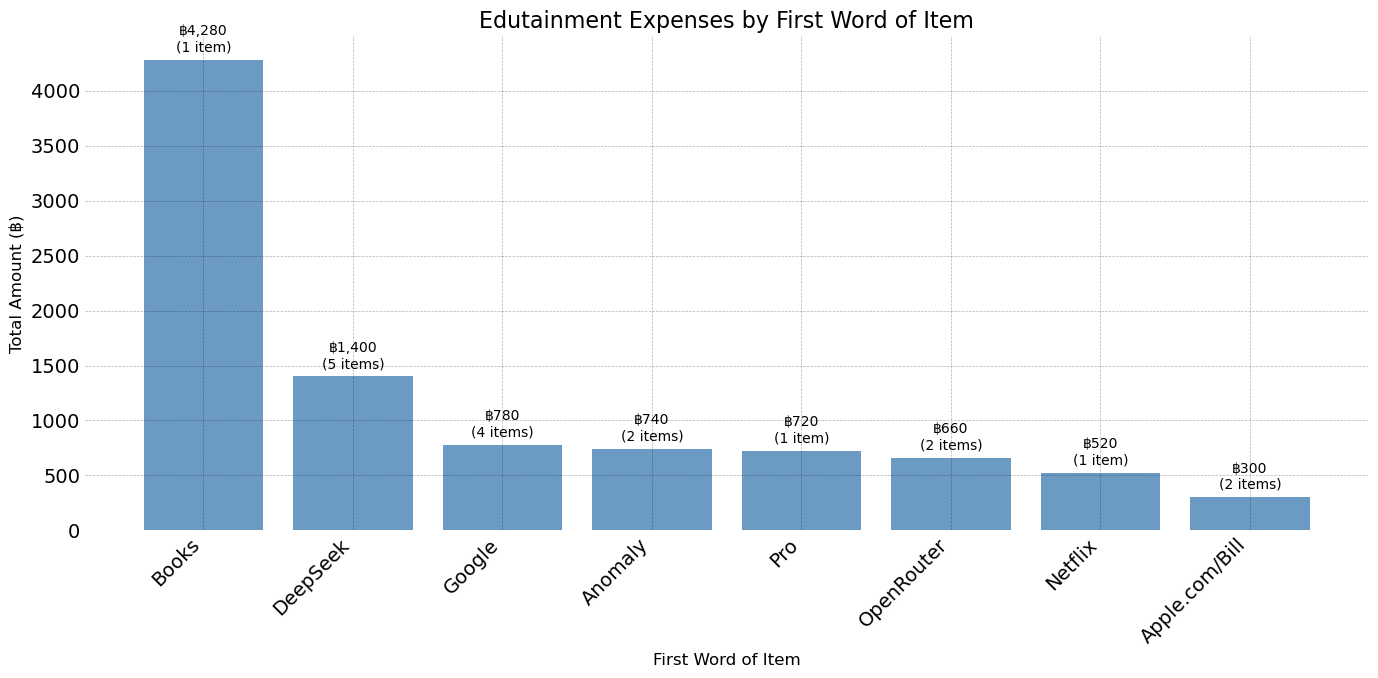

In [23]:
%matplotlib inline
import calendar
import matplotlib.pyplot as plt
plt.style.use('my_custom_style')
import pandas as pd
from sqlalchemy import create_engine
from datetime import date, timedelta
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from itables import show
pd.options.display.max_rows = 31

engine = create_engine("sqlite:///c:\\ruby\\expense\\db\\development.sqlite3")
conn = engine.connect()

today = date.today()
print(today)

# Define a formatting function that converts a float to a string with two decimal places
def to_currency(x):
    return '฿{:,.2f}'.format(x)    

# Define a formatting function that converts an integer to a string with comma and no decimal places
def to_integer(x):
    return '{:,.0f}'.format(x)

# create a date object
date = pd.to_datetime('2026-8-31')

# find the beginning of the month for the given date
bom = date.to_period('M').start_time
eom = date.to_period('M').end_time
bom = bom.date()
eom = eom.date()
print(f'Month start: {bom}')
print(f'Month end: {eom}')

sql = """
    SELECT date,amount,C.name AS item, G.name AS kind 
    FROM transactions T 
    JOIN categories C ON category_id = C.id 
    JOIN groups G ON group_id = G.id 
    WHERE date BETWEEN "{}" AND "{}" 
    AND group_id = 3
    ORDER BY date
""".format(bom, eom)

df_month = pd.read_sql(sql, conn)
df_month

# Calculate total monthly expense
monthly_amt = df_month.amount.sum()
monthly_amt_fmt = to_currency(monthly_amt)
print(f"Total Monthly Expense: {monthly_amt_fmt}")

# Create new column with first word of item
df_month['item_first_word'] = df_month['item'].str.split().str[0]

# Display the dataframe with the new column
print("\nDataFrame with first word column:")
df_month

# Group by the new column and calculate sum
grouped_by_first_word = df_month.groupby('item_first_word').agg({
    'amount': ['sum', 'count', 'mean']
}).reset_index()

# Rename columns for better readability
grouped_by_first_word.columns = ['First Word', 'Total Amount', 'Transaction Count', 'Average Amount']

# Sort by total amount descending
grouped_by_first_word = grouped_by_first_word.sort_values('Total Amount', ascending=False)

# Apply currency formatting to amount columns
grouped_by_first_word['Total Amount Formatted'] = grouped_by_first_word['Total Amount'].apply(to_currency)
grouped_by_first_word['Average Amount Formatted'] = grouped_by_first_word['Average Amount'].apply(to_currency)

# Display the grouped results
print("\nGrouped by first word of item:")
grouped_by_first_word

# Create a single bar chart with transaction count in the description
fig, ax = plt.subplots(figsize=(14, 7))

# Create bar chart
bars = ax.bar(grouped_by_first_word['First Word'], grouped_by_first_word['Total Amount'], 
              color='steelblue', alpha=0.8)

# Set title and labels
ax.set_title('Edutainment Expenses by First Word of Item', fontsize=16)
ax.set_xlabel('First Word of Item', fontsize=12)
ax.set_ylabel('Total Amount (฿)', fontsize=12)

# Rotate x-axis labels
ax.tick_params(axis='x', labelrotation=45)
ax.set_xticklabels(ax.get_xticklabels(), ha='right')

# Add value labels on top of bars showing amount and transaction count
for i, bar in enumerate(bars):
    height = bar.get_height()
    count = grouped_by_first_word['Transaction Count'].iloc[i]
    
    # Create description with transaction count
    if count == 1:
        txn_text = f'{count} item'
    else:
        txn_text = f'{count} items'
    
    # Add text on top of bar
    ax.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'฿{height:,.0f}\n({txn_text})',
             ha='center', va='bottom', fontsize=10)

# Add grid for better readability
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()